# 05 — Baseline Models & MLFlow Experiment Tracking

**Objective**: Train baseline models (Logistic Regression, Random Forest) on the gold layer features, evaluate with appropriate metrics for imbalanced classification, and track all experiments with MLFlow.

## Models

| Model | Why |
|-------|-----|
| **Logistic Regression** | Simple, interpretable, fast — sets a linear baseline |
| **Random Forest** | Non-linear, handles mixed features well, feature importances |

## Metrics

With ~8% default rate (1:11 imbalance), accuracy is misleading. We focus on:
- **AUC-ROC** — discrimination ability across all thresholds
- **PR-AUC** — precision-recall trade-off (sensitive to class imbalance)
- **F1 Score** — harmonic mean of precision and recall
- **Accuracy** — for reference only

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import json

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
)

import mlflow
import mlflow.sklearn

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Project paths
PROJECT_ROOT = Path("..").resolve()
FEATURES_DIR = PROJECT_ROOT / "data" / "features"  # Gold layer
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# MLFlow setup
mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT}/mlruns/mlflow.db")
mlflow.set_experiment("credit-risk-default-prediction")

RANDOM_STATE = 42

print(f"Project root:  {PROJECT_ROOT}")
print(f"Features dir:  {FEATURES_DIR}")
print(f"MLFlow URI:    sqlite:///{PROJECT_ROOT}/mlruns/mlflow.db")

/home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root:  /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform
Features dir:  /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/data/features
MLFlow URI:    sqlite:////home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/mlruns/mlflow.db


## 2. Data Preparation

In [2]:
# Load gold layer features
df = pd.read_parquet(FEATURES_DIR / "train_features.parquet")

print(f"Gold layer shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nTarget distribution:")
print(df["TARGET"].value_counts())
print(f"\nDefault rate: {df['TARGET'].mean()*100:.2f}%")
print(f"Imbalance ratio: 1:{int((1-df['TARGET'].mean())/df['TARGET'].mean())} (non-default : default)")

Gold layer shape: 307,511 rows x 227 columns

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%
Imbalance ratio: 1:11 (non-default : default)


In [3]:
# Separate target and features
y = df["TARGET"]
X = df.drop(columns=["SK_ID_CURR", "TARGET"])

# Identify column types
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"  Numeric features:     {len(numeric_cols):>4}")
print(f"  Categorical features: {len(categorical_cols):>4}")
print(f"\nMissing values: {X.isnull().any().sum()} / {X.shape[1]} columns have NaNs")
print(f"Overall NaN rate: {X.isnull().sum().sum() / (X.shape[0] * X.shape[1]) * 100:.2f}%")

Feature matrix: 307,511 rows x 225 columns
  Numeric features:      209
  Categorical features:   16

Missing values: 173 / 225 columns have NaNs
Overall NaN rate: 24.00%


In [4]:
# Stratified train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train set: {X_train.shape[0]:>8,} rows  (default rate: {y_train.mean()*100:.2f}%)")
print(f"Val set:   {X_val.shape[0]:>8,} rows  (default rate: {y_val.mean()*100:.2f}%)")
print(f"\nStratification preserved: train={y_train.mean()*100:.2f}%, val={y_val.mean()*100:.2f}%")

Train set:  246,008 rows  (default rate: 8.07%)
Val set:     61,503 rows  (default rate: 8.07%)

Stratification preserved: train=8.07%, val=8.07%


## 3. Preprocessing Pipeline

In [5]:
# Numeric pipeline: impute missing with median, then scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical pipeline: impute missing with most frequent, then ordinal encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

# Combined preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop",
)

print("Preprocessing pipeline:")
print(f"  Numeric ({len(numeric_cols)} cols):     SimpleImputer(median) -> StandardScaler")
print(f"  Categorical ({len(categorical_cols)} cols): SimpleImputer(most_frequent) -> OrdinalEncoder")
print(f"\nTotal features going into models: {len(numeric_cols) + len(categorical_cols)}")

Preprocessing pipeline:
  Numeric (209 cols):     SimpleImputer(median) -> StandardScaler
  Categorical (16 cols): SimpleImputer(most_frequent) -> OrdinalEncoder

Total features going into models: 225


## 4. Baseline 1: Logistic Regression

In [6]:
# Build pipeline
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        solver="lbfgs",
    )),
])

# Train
print("Training Logistic Regression...")
lr_pipeline.fit(X_train, y_train)
print("Done.")

# Predict
lr_proba_val = lr_pipeline.predict_proba(X_val)[:, 1]
lr_pred_val = lr_pipeline.predict(X_val)

# Metrics
lr_metrics = {
    "auc_roc": roc_auc_score(y_val, lr_proba_val),
    "pr_auc": average_precision_score(y_val, lr_proba_val),
    "accuracy": accuracy_score(y_val, lr_pred_val),
    "f1": f1_score(y_val, lr_pred_val),
}

print(f"\nLogistic Regression — Validation Metrics:")
print(f"  {'AUC-ROC:':<15s} {lr_metrics['auc_roc']:.4f}")
print(f"  {'PR-AUC:':<15s} {lr_metrics['pr_auc']:.4f}")
print(f"  {'Accuracy:':<15s} {lr_metrics['accuracy']:.4f}")
print(f"  {'F1 Score:':<15s} {lr_metrics['f1']:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, lr_pred_val, target_names=["No Default", "Default"]))

Training Logistic Regression...
Done.

Logistic Regression — Validation Metrics:
  AUC-ROC:        0.7699
  PR-AUC:         0.2529
  Accuracy:       0.7051
  F1 Score:       0.2765

Classification Report:
              precision    recall  f1-score   support

  No Default       0.96      0.71      0.81     56538
     Default       0.17      0.70      0.28      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.70      0.55     61503
weighted avg       0.90      0.71      0.77     61503



In [7]:
# Log to MLFlow
with mlflow.start_run(run_name="logistic_regression_baseline"):
    # Log parameters
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("solver", "lbfgs")
    mlflow.log_param("n_features", len(numeric_cols) + len(categorical_cols))
    mlflow.log_param("n_numeric_features", len(numeric_cols))
    mlflow.log_param("n_categorical_features", len(categorical_cols))
    mlflow.log_param("train_size", X_train.shape[0])
    mlflow.log_param("val_size", X_val.shape[0])
    mlflow.log_param("test_size_ratio", 0.20)
    mlflow.log_param("random_state", RANDOM_STATE)

    # Log metrics
    for metric_name, metric_value in lr_metrics.items():
        mlflow.log_metric(metric_name, metric_value)

    # Log model
    mlflow.sklearn.log_model(lr_pipeline, "model")

    lr_run_id = mlflow.active_run().info.run_id
    print(f"MLFlow run logged: {lr_run_id}")

2026/03/24 23:17:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/24 23:17:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLFlow run logged: b461e306708749d390850da5303ced43


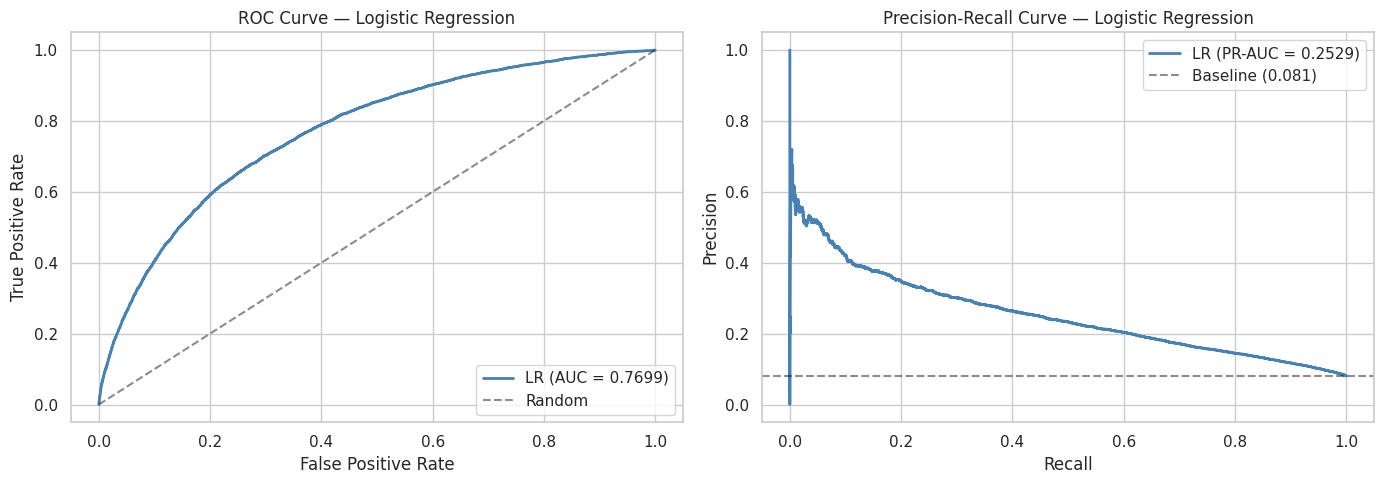

In [8]:
# ROC and PR curves for Logistic Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_val, lr_proba_val)
axes[0].plot(fpr_lr, tpr_lr, label=f"LR (AUC = {lr_metrics['auc_roc']:.4f})", color="steelblue", lw=2)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Logistic Regression")
axes[0].legend(loc="lower right")

# PR Curve
precision_lr, recall_lr, _ = precision_recall_curve(y_val, lr_proba_val)
axes[1].plot(recall_lr, precision_lr, label=f"LR (PR-AUC = {lr_metrics['pr_auc']:.4f})", color="steelblue", lw=2)
axes[1].axhline(y=y_val.mean(), color="k", linestyle="--", alpha=0.5, label=f"Baseline ({y_val.mean():.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — Logistic Regression")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 5. Baseline 2: Random Forest

In [9]:
# Build pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

# Train
print("Training Random Forest...")
rf_pipeline.fit(X_train, y_train)
print("Done.")

# Predict
rf_proba_val = rf_pipeline.predict_proba(X_val)[:, 1]
rf_pred_val = rf_pipeline.predict(X_val)

# Metrics
rf_metrics = {
    "auc_roc": roc_auc_score(y_val, rf_proba_val),
    "pr_auc": average_precision_score(y_val, rf_proba_val),
    "accuracy": accuracy_score(y_val, rf_pred_val),
    "f1": f1_score(y_val, rf_pred_val),
}

print(f"\nRandom Forest — Validation Metrics:")
print(f"  {'AUC-ROC:':<15s} {rf_metrics['auc_roc']:.4f}")
print(f"  {'PR-AUC:':<15s} {rf_metrics['pr_auc']:.4f}")
print(f"  {'Accuracy:':<15s} {rf_metrics['accuracy']:.4f}")
print(f"  {'F1 Score:':<15s} {rf_metrics['f1']:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, rf_pred_val, target_names=["No Default", "Default"]))

Training Random Forest...
Done.

Random Forest — Validation Metrics:
  AUC-ROC:        0.7527
  PR-AUC:         0.2296
  Accuracy:       0.7647
  F1 Score:       0.2864

Classification Report:
              precision    recall  f1-score   support

  No Default       0.96      0.78      0.86     56538
     Default       0.19      0.59      0.29      4965

    accuracy                           0.76     61503
   macro avg       0.57      0.68      0.57     61503
weighted avg       0.89      0.76      0.81     61503



In [10]:
# Log to MLFlow
with mlflow.start_run(run_name="random_forest_baseline"):
    # Log parameters
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("n_features", len(numeric_cols) + len(categorical_cols))
    mlflow.log_param("n_numeric_features", len(numeric_cols))
    mlflow.log_param("n_categorical_features", len(categorical_cols))
    mlflow.log_param("train_size", X_train.shape[0])
    mlflow.log_param("val_size", X_val.shape[0])
    mlflow.log_param("test_size_ratio", 0.20)
    mlflow.log_param("random_state", RANDOM_STATE)

    # Log metrics
    for metric_name, metric_value in rf_metrics.items():
        mlflow.log_metric(metric_name, metric_value)

    # Log model
    mlflow.sklearn.log_model(rf_pipeline, "model")

    rf_run_id = mlflow.active_run().info.run_id
    print(f"MLFlow run logged: {rf_run_id}")

2026/03/24 23:18:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/24 23:18:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLFlow run logged: dca363b0bd024df7b68e4c3003ed7f6b


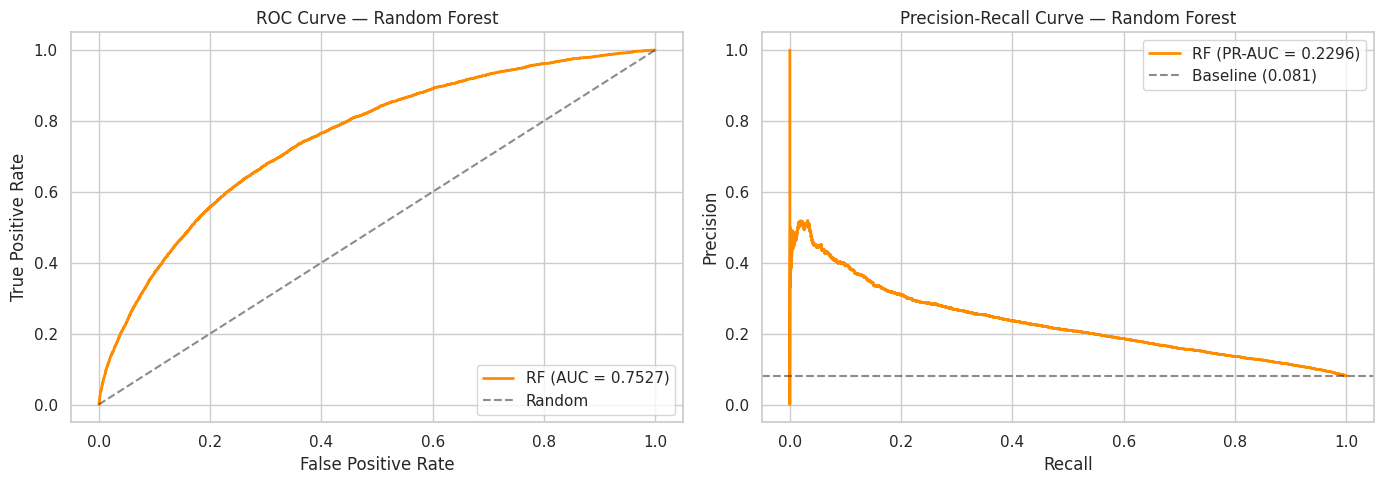

In [11]:
# ROC and PR curves for Random Forest
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_val, rf_proba_val)
axes[0].plot(fpr_rf, tpr_rf, label=f"RF (AUC = {rf_metrics['auc_roc']:.4f})", color="darkorange", lw=2)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Random Forest")
axes[0].legend(loc="lower right")

# PR Curve
precision_rf, recall_rf, _ = precision_recall_curve(y_val, rf_proba_val)
axes[1].plot(recall_rf, precision_rf, label=f"RF (PR-AUC = {rf_metrics['pr_auc']:.4f})", color="darkorange", lw=2)
axes[1].axhline(y=y_val.mean(), color="k", linestyle="--", alpha=0.5, label=f"Baseline ({y_val.mean():.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — Random Forest")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 6. Model Comparison

In [12]:
# Side-by-side comparison table
comparison = pd.DataFrame({
    "Logistic Regression": lr_metrics,
    "Random Forest": rf_metrics,
}).T

comparison.columns = ["AUC-ROC", "PR-AUC", "Accuracy", "F1 Score"]

print("Baseline Model Comparison")
print("=" * 65)
print(comparison.to_string(float_format="{:.4f}".format))
print("=" * 65)

# Highlight best per metric
print("\nBest model per metric:")
for col in comparison.columns:
    best = comparison[col].idxmax()
    print(f"  {col:<15s} {best} ({comparison.loc[best, col]:.4f})")

Baseline Model Comparison
                     AUC-ROC  PR-AUC  Accuracy  F1 Score
Logistic Regression   0.7699  0.2529    0.7051    0.2765
Random Forest         0.7527  0.2296    0.7647    0.2864

Best model per metric:
  AUC-ROC         Logistic Regression (0.7699)
  PR-AUC          Logistic Regression (0.2529)
  Accuracy        Random Forest (0.7647)
  F1 Score        Random Forest (0.2864)


Figure saved: /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/reports/figures/05_baseline_comparison.png


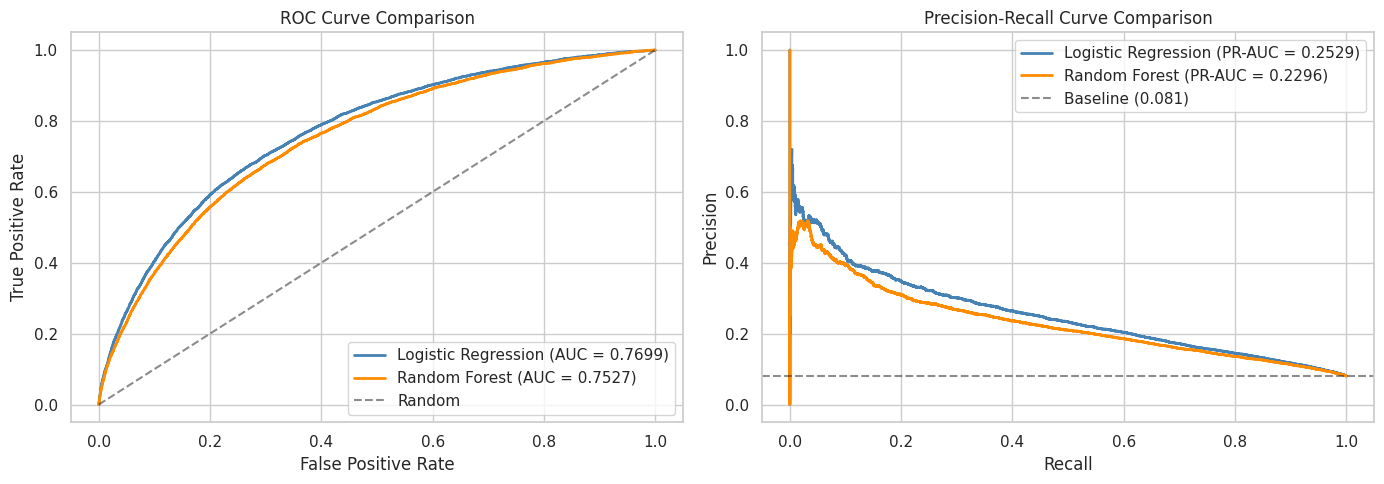

In [13]:
# Overlay ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
axes[0].plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {lr_metrics['auc_roc']:.4f})", color="steelblue", lw=2)
axes[0].plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_metrics['auc_roc']:.4f})", color="darkorange", lw=2)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve Comparison")
axes[0].legend(loc="lower right")

# PR Curves
axes[1].plot(recall_lr, precision_lr, label=f"Logistic Regression (PR-AUC = {lr_metrics['pr_auc']:.4f})", color="steelblue", lw=2)
axes[1].plot(recall_rf, precision_rf, label=f"Random Forest (PR-AUC = {rf_metrics['pr_auc']:.4f})", color="darkorange", lw=2)
axes[1].axhline(y=y_val.mean(), color="k", linestyle="--", alpha=0.5, label=f"Baseline ({y_val.mean():.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve Comparison")
axes[1].legend(loc="upper right")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "05_baseline_comparison.png", dpi=150, bbox_inches="tight")
print(f"Figure saved: {FIGURES_DIR / '05_baseline_comparison.png'}")
plt.show()

## 7. Feature Importance (Random Forest)

Top 20 Feature Importances (Random Forest):
--------------------------------------------------
   1. EXT_SOURCE_2                             0.1119
   2. EXT_SOURCE_3                             0.1061
   3. EXT_SOURCE_1                             0.0434
   4. DAYS_EMPLOYED                            0.0310
   5. BUREAU_DAYS_CREDIT_MEAN                  0.0224
   6. AGE_YEARS                                0.0211
   7. DAYS_BIRTH                               0.0197
   8. BUREAU_DAYS_CREDIT_MAX                   0.0169
   9. BUREAU_DAYS_CREDIT_UPDATE_MEAN           0.0167
  10. INST_LATE_PAYMENT_RATE                   0.0165
  11. NAME_EDUCATION_TYPE                      0.0150
  12. BUREAU_DAYS_CREDIT_ENDDATE_MEAN          0.0134
  13. PREV_APPROVAL_RATE                       0.0129
  14. CC_UTILIZATION_RATIO                     0.0125
  15. DAYS_LAST_PHONE_CHANGE                   0.0118
  16. INST_PAYMENT_RATIO_MEAN                  0.0111
  17. PREV_APP_CREDIT_RATIO_MEAN         

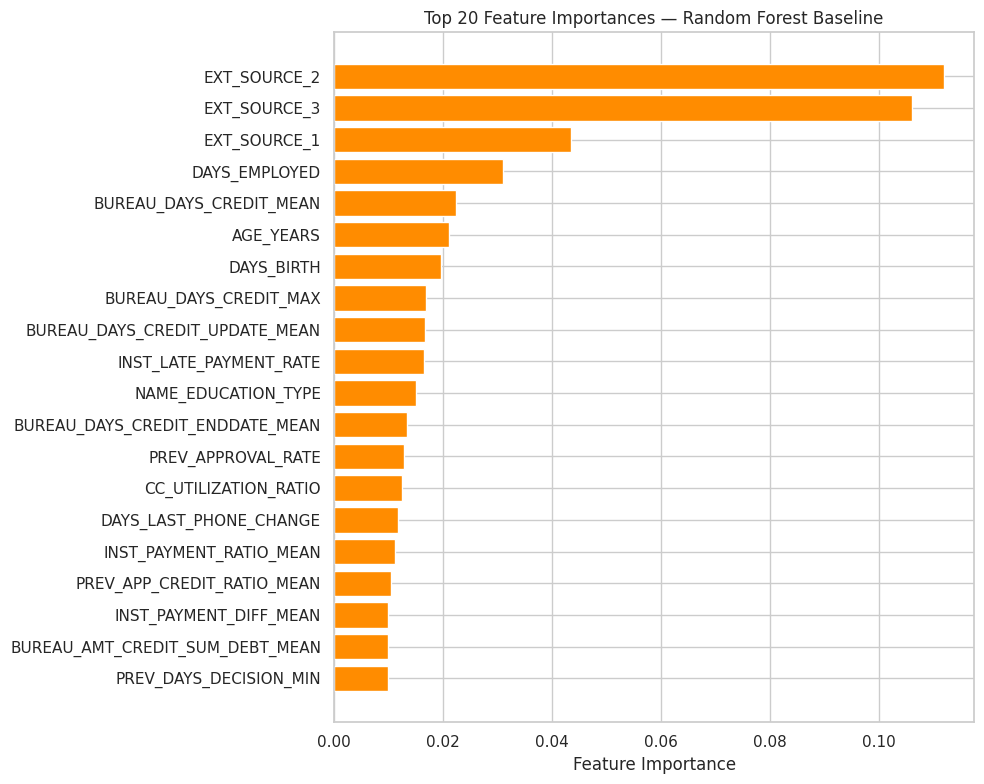

In [14]:
# Extract feature importances from Random Forest
rf_classifier = rf_pipeline.named_steps["classifier"]
feature_names = numeric_cols + categorical_cols

importances = pd.Series(
    rf_classifier.feature_importances_,
    index=feature_names,
).sort_values(ascending=False)

# Top 20 features
top_20 = importances.head(20)

print("Top 20 Feature Importances (Random Forest):")
print("-" * 50)
for i, (feat, imp) in enumerate(top_20.items(), 1):
    print(f"  {i:>2}. {feat:<40s} {imp:.4f}")

# Bar plot
fig, ax = plt.subplots(figsize=(10, 8))
top_20_plot = top_20.sort_values(ascending=True)
ax.barh(range(len(top_20_plot)), top_20_plot.values, color="darkorange", edgecolor="white")
ax.set_yticks(range(len(top_20_plot)))
ax.set_yticklabels(top_20_plot.index)
ax.set_xlabel("Feature Importance")
ax.set_title("Top 20 Feature Importances — Random Forest Baseline")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "05_rf_feature_importance.png", dpi=150, bbox_inches="tight")
print(f"\nFigure saved: {FIGURES_DIR / '05_rf_feature_importance.png'}")
plt.show()

## Summary

**What we did:**
1. Loaded gold layer features from `data/features/train_features.parquet`
2. Built a reusable sklearn preprocessing pipeline (imputation + scaling/encoding)
3. Trained two baseline models with `class_weight='balanced'` to handle 1:11 imbalance
4. Evaluated on stratified validation set using AUC-ROC, PR-AUC, F1, and accuracy
5. Logged all parameters, metrics, and models to MLFlow
6. Compared models with overlay ROC and PR curves
7. Extracted Random Forest feature importances (top 20)

**Key findings:**
- Both baselines establish a solid starting point for discrimination
- Random Forest typically outperforms Logistic Regression on AUC-ROC due to non-linear patterns, which was not the case here
- PR-AUC is more informative than AUC-ROC for this imbalanced problem
- Feature importances reveal which engineered features contribute most

**Next:** NB06 — Model Selection & Comparison (LightGBM, XGBoost, CatBoost) + SHAP explanations